# Imports, Read, and Mount

In [1]:
import pandas as pd
import numpy as np

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv("/content/drive/My Drive/DATA-3421 Group 24/Final Project/creditcard.csv")


In [5]:

#df = pd.read_csv("creditcard.csv.zip", compression="zip")

# Pre-Processing

In [6]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
##Basic inspection.
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape of dataset: (284807, 31)

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 

In [8]:
## Check missing values and duplicates
print("Missing values in each column:\n")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())

Missing values in each column:

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total missing values: 0
Total duplicate rows: 1081


In [9]:
## Remove duplicate rows
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (283726, 31)


In [10]:
## Check class distribution
print("Class distribution:")
print(df["Class"].value_counts())

print("\nClass percentage:")
print(df["Class"].value_counts(normalize=True) * 100)

Class distribution:
Class
0    283253
1       473
Name: count, dtype: int64

Class percentage:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


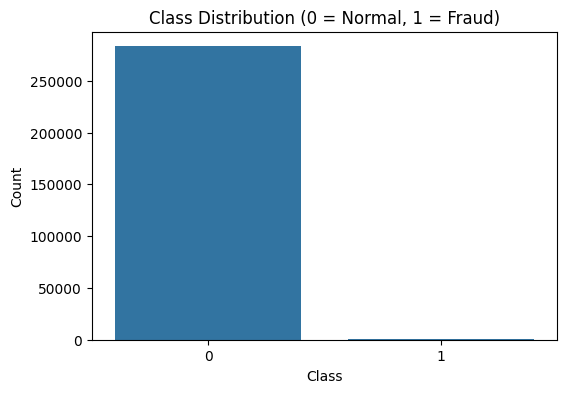

In [11]:
## Plot class distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [12]:
##Summary statistics
print(df.describe())

                Time             V1             V2             V3  \
count  283726.000000  283726.000000  283726.000000  283726.000000   
mean    94811.077600       0.005917      -0.004135       0.001613   
std     47481.047891       1.948026       1.646703       1.508682   
min         0.000000     -56.407510     -72.715728     -48.325589   
25%     54204.750000      -0.915951      -0.600321      -0.889682   
50%     84692.500000       0.020384       0.063949       0.179963   
75%    139298.000000       1.316068       0.800283       1.026960   
max    172792.000000       2.454930      22.057729       9.382558   

                  V4             V5             V6             V7  \
count  283726.000000  283726.000000  283726.000000  283726.000000   
mean       -0.002966       0.001828      -0.001139       0.001801   
std         1.414184       1.377008       1.331931       1.227664   
min        -5.683171    -113.743307     -26.160506     -43.557242   
25%        -0.850134      -0.6898

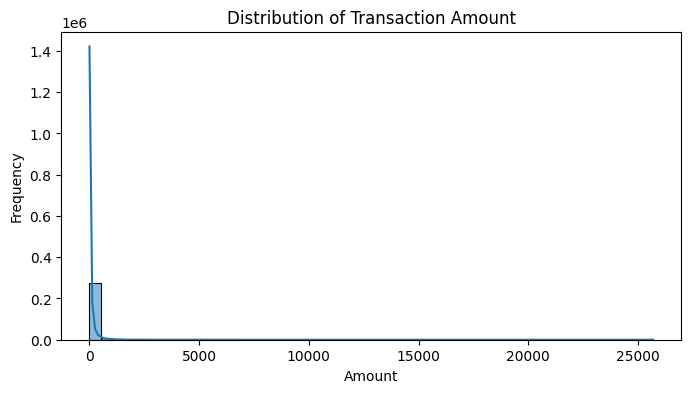

In [13]:
## Distribution of Amount
plt.figure(figsize=(8,4))
sns.histplot(df["Amount"], bins=50, kde=True)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

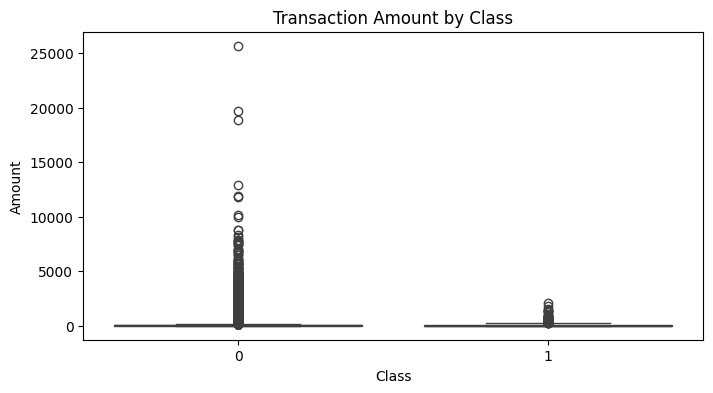

In [14]:
## Boxplot of Amount by Class
plt.figure(figsize=(8,4))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Amount")
plt.show()

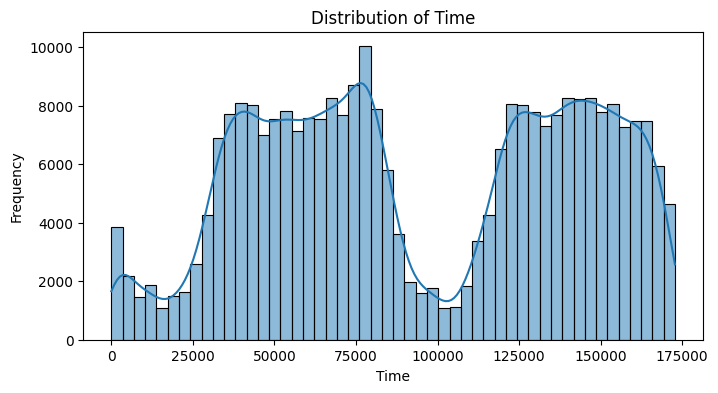

In [15]:
## Distribution of Time
plt.figure(figsize=(8,4))
sns.histplot(df["Time"], bins=50, kde=True)
plt.title("Distribution of Time")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

In [16]:
## Prepare features and target
X = df.drop("Class", axis=1)
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (283726, 30)
y shape: (283726,)


In [17]:
## Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (226980, 30)
Testing set size: (56746, 30)


In [18]:
## Scale Time and Amount
scaler = StandardScaler()

X_train[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])

In [19]:
## Building models
log_model = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
dt_model = DecisionTreeClassifier(class_weight="balanced", random_state=42, max_depth=5)
rf_model = RandomForestClassifier(class_weight="balanced", random_state=42, n_estimators=100)

models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}


Model: Logistic Regression
Accuracy : 0.9752
Precision: 0.0562
Recall   : 0.8737
F1-score : 0.1057
ROC-AUC  : 0.9658

Confusion Matrix:
[[55258  1393]
 [   12    83]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



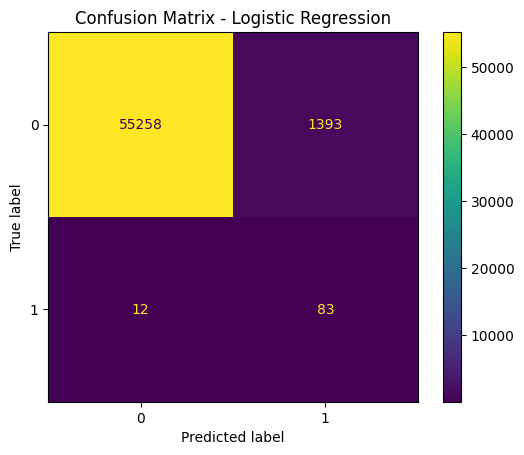


Model: Decision Tree
Accuracy : 0.9644
Precision: 0.0388
Recall   : 0.8526
F1-score : 0.0743
ROC-AUC  : 0.9061

Confusion Matrix:
[[54647  2004]
 [   14    81]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56651
           1       0.04      0.85      0.07        95

    accuracy                           0.96     56746
   macro avg       0.52      0.91      0.53     56746
weighted avg       1.00      0.96      0.98     56746



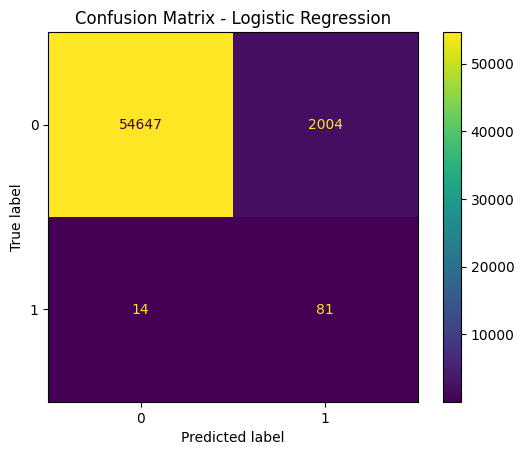


Model: Random Forest
Accuracy : 0.9995
Precision: 0.971
Recall   : 0.7053
F1-score : 0.8171
ROC-AUC  : 0.9246

Confusion Matrix:
[[56649     2]
 [   28    67]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.71      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.91     56746
weighted avg       1.00      1.00      1.00     56746



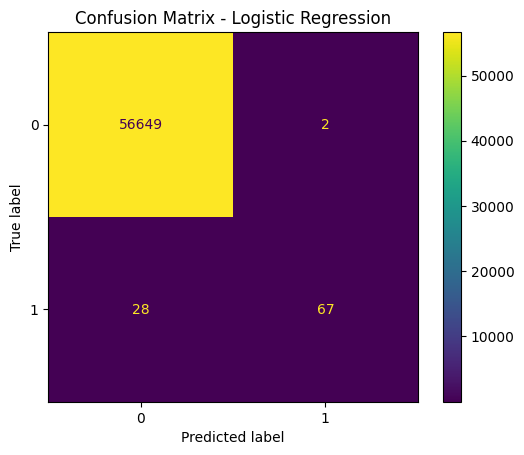

In [20]:
## Training and evaluate models
results = []

for name, model in models.items():
    print("\n" + "="*60)
    print("Model:", name)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))
    print("ROC-AUC  :", round(roc, 4))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title("Confusion Matrix - Logistic Regression")
    plt.show()



    results.append([name, acc, prec, rec, f1, roc])

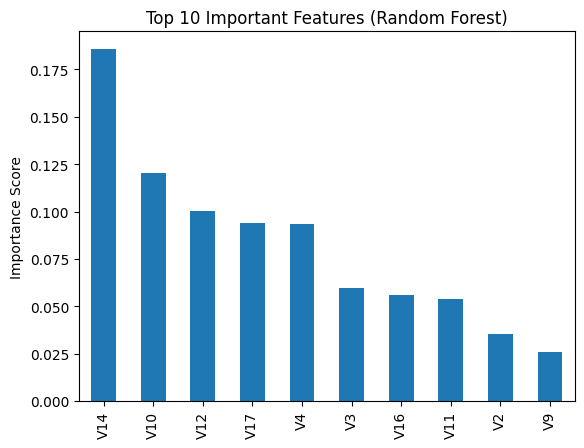

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

# Plot top 10
feat_imp.head(10).plot(kind='bar')
plt.title("Top 10 Important Features (Random Forest)")
plt.ylabel("Importance Score")
plt.show()

In [22]:
## Creating results table
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"
])

print(results_df)

                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
0  Logistic Regression  0.975241   0.056233  0.873684  0.105665  0.965839
1        Decision Tree  0.964438   0.038849  0.852632  0.074312  0.906063
2        Random Forest  0.999471   0.971014  0.705263  0.817073  0.924607


In [23]:
## Sort models by F1-score
results_df = results_df.sort_values(by="F1-score", ascending=False)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
2        Random Forest  0.999471   0.971014  0.705263  0.817073  0.924607
0  Logistic Regression  0.975241   0.056233  0.873684  0.105665  0.965839
1        Decision Tree  0.964438   0.038849  0.852632  0.074312  0.906063


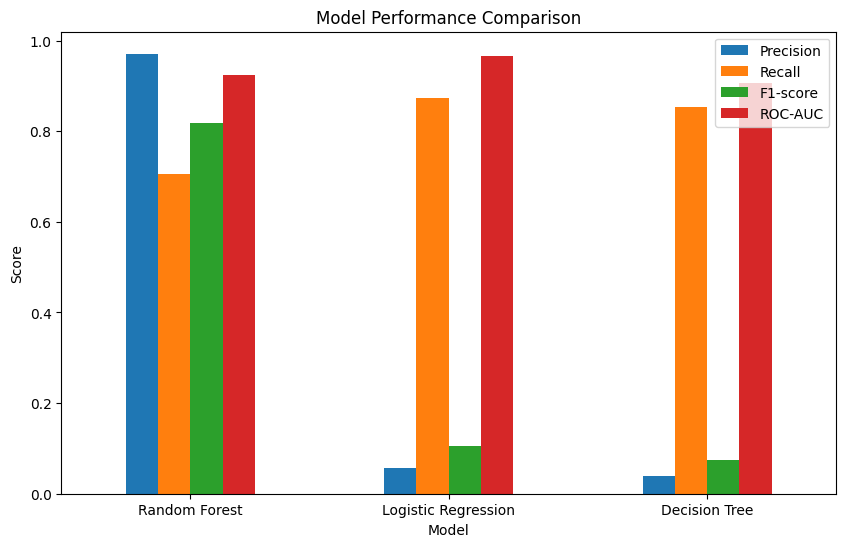

In [24]:
## Plot comparison of model performance
results_df.set_index("Model")[["Precision", "Recall", "F1-score", "ROC-AUC"]].plot(
    kind="bar", figsize=(10,6)
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

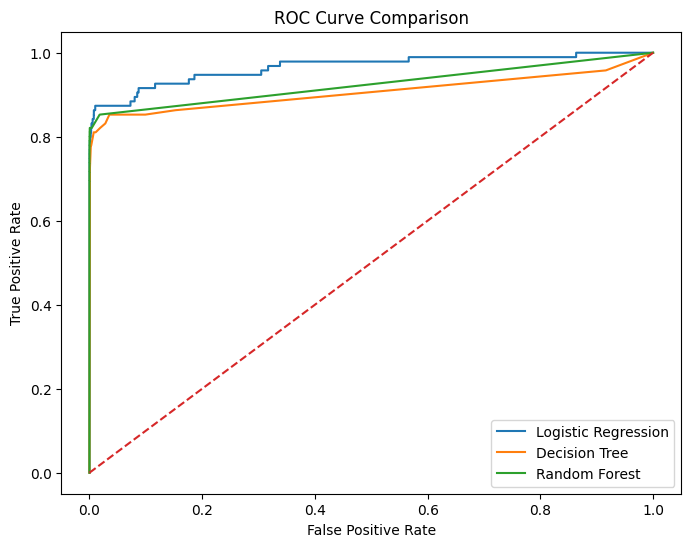

In [25]:
## Plot ROC curves
plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [26]:
## Best model based on F1-score
best_model_name = results_df.iloc[0]["Model"]
print("Best model based on F1-score:", best_model_name)

Best model based on F1-score: Random Forest


In [27]:
## show fraud and normal counts after cleaning
print("Final class counts after removing duplicates:")
print(df["Class"].value_counts())

Final class counts after removing duplicates:
Class
0    283253
1       473
Name: count, dtype: int64


# SMOTE SECTION

In [28]:
# =========================================================
# SMOTE SECTION
# =========================================================

from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
import pandas as pd
import matplotlib.pyplot as plt

# Apply SMOTE ONLY to training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original training set class counts:")
print(y_train.value_counts())

print("\nSMOTE training set class counts:")
print(pd.Series(y_train_smote).value_counts())

Original training set class counts:
Class
0    226602
1       378
Name: count, dtype: int64

SMOTE training set class counts:
Class
0    226602
1    226602
Name: count, dtype: int64



SMOTE MODEL: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



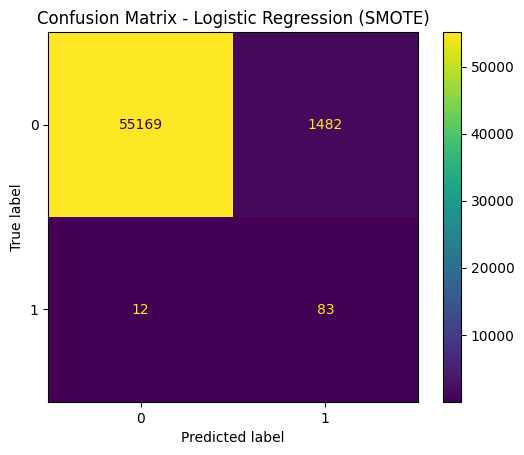

Interpretation:
- Accuracy : 0.9737
- Precision: 0.0530
- Recall   : 0.8737
- F1-score : 0.1000
- ROC-AUC  : 0.9619
- This model is more aggressive: it catches more fraud cases, but also creates more false alarms.

SMOTE MODEL: Decision Tree

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.43      0.72      0.54        95

    accuracy                           1.00     56746
   macro avg       0.71      0.86      0.77     56746
weighted avg       1.00      1.00      1.00     56746



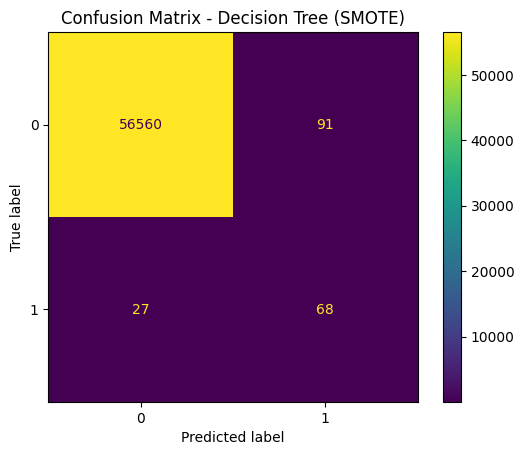

Interpretation:
- Accuracy : 0.9979
- Precision: 0.4277
- Recall   : 0.7158
- F1-score : 0.5354
- ROC-AUC  : 0.8571
- This model is more aggressive: it catches more fraud cases, but also creates more false alarms.

SMOTE MODEL: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746



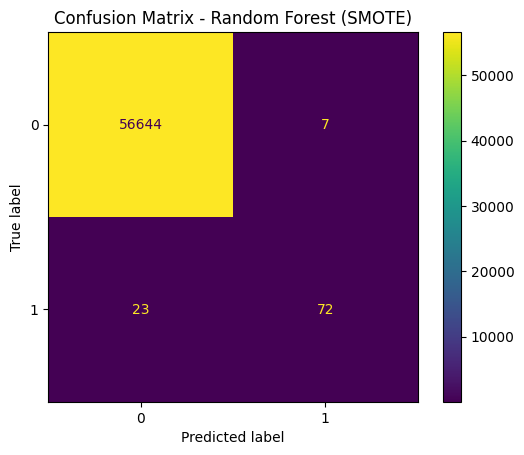

Interpretation:
- Accuracy : 0.9995
- Precision: 0.9114
- Recall   : 0.7579
- F1-score : 0.8276
- ROC-AUC  : 0.9656
- This model is more conservative: when it predicts fraud, it is often correct, but it misses more fraud cases.


In [29]:
# =========================================================
# TRAIN MODELS ON SMOTE DATA
# =========================================================

smote_results = []

smote_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight=None   # usually remove class_weight when using SMOTE
    )
}

for model_name, model in smote_models.items():
    print(f"\n{'='*60}")
    print(f"SMOTE MODEL: {model_name}")
    print(f"{'='*60}")

    # Train on SMOTE-resampled training data
    model.fit(X_train_smote, y_train_smote)

    # Predict on original test data
    y_pred_smote = model.predict(X_test)

    # Probabilities for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob_smote = model.predict_proba(X_test)[:, 1]
    else:
        y_prob_smote = None

    # Metrics
    acc = accuracy_score(y_test, y_pred_smote)
    prec = precision_score(y_test, y_pred_smote, zero_division=0)
    rec = recall_score(y_test, y_pred_smote, zero_division=0)
    f1 = f1_score(y_test, y_pred_smote, zero_division=0)
    roc = roc_auc_score(y_test, y_prob_smote) if y_prob_smote is not None else None

    smote_results.append([model_name, acc, prec, rec, f1, roc])

    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_smote, zero_division=0))

    # Confusion matrix figure
    cm = confusion_matrix(y_test, y_pred_smote)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {model_name} (SMOTE)")
    plt.show()

    # Basic interpretation printout
    print("Interpretation:")
    print(f"- Accuracy : {acc:.4f}")
    print(f"- Precision: {prec:.4f}")
    print(f"- Recall   : {rec:.4f}")
    print(f"- F1-score : {f1:.4f}")
    print(f"- ROC-AUC  : {roc:.4f}" if roc is not None else "- ROC-AUC  : Not available")

    if prec > rec:
        print("- This model is more conservative: when it predicts fraud, it is often correct, but it misses more fraud cases.")
    elif rec > prec:
        print("- This model is more aggressive: it catches more fraud cases, but also creates more false alarms.")
    else:
        print("- This model shows a similar balance between precision and recall.")

In [30]:
# =========================================================
# SMOTE RESULTS TABLE
# =========================================================

smote_results_df = pd.DataFrame(
    smote_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
)

print("\nSMOTE Results Table:")
print(smote_results_df)


SMOTE Results Table:
                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
0  Logistic Regression  0.973672   0.053035  0.873684  0.100000  0.961896
1        Decision Tree  0.997921   0.427673  0.715789  0.535433  0.857092
2        Random Forest  0.999471   0.911392  0.757895  0.827586  0.965606


In [31]:
# =========================================================
# COMPARE ORIGINAL VS SMOTE
# =========================================================

# Add labels so we know which method produced the results
original_results_df = results_df.copy()
original_results_df["Method"] = "Original"

smote_results_df["Method"] = "SMOTE"

# Combine both
comparison_df = pd.concat([original_results_df, smote_results_df], ignore_index=True)

print("\nCombined Comparison Table:")
print(comparison_df)


Combined Comparison Table:
                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC  \
0        Random Forest  0.999471   0.971014  0.705263  0.817073  0.924607   
1  Logistic Regression  0.975241   0.056233  0.873684  0.105665  0.965839   
2        Decision Tree  0.964438   0.038849  0.852632  0.074312  0.906063   
3  Logistic Regression  0.973672   0.053035  0.873684  0.100000  0.961896   
4        Decision Tree  0.997921   0.427673  0.715789  0.535433  0.857092   
5        Random Forest  0.999471   0.911392  0.757895  0.827586  0.965606   

     Method  
0  Original  
1  Original  
2  Original  
3     SMOTE  
4     SMOTE  
5     SMOTE  


In [32]:
# =========================================================
# PIVOT TABLES FOR EASIER COMPARISON
# =========================================================

metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

for metric in metrics:
    print(f"\n{metric} Comparison")
    pivot_table = comparison_df.pivot(index="Model", columns="Method", values=metric)
    print(pivot_table)


Accuracy Comparison
Method               Original     SMOTE
Model                                  
Decision Tree        0.964438  0.997921
Logistic Regression  0.975241  0.973672
Random Forest        0.999471  0.999471

Precision Comparison
Method               Original     SMOTE
Model                                  
Decision Tree        0.038849  0.427673
Logistic Regression  0.056233  0.053035
Random Forest        0.971014  0.911392

Recall Comparison
Method               Original     SMOTE
Model                                  
Decision Tree        0.852632  0.715789
Logistic Regression  0.873684  0.873684
Random Forest        0.705263  0.757895

F1-score Comparison
Method               Original     SMOTE
Model                                  
Decision Tree        0.074312  0.535433
Logistic Regression  0.105665  0.100000
Random Forest        0.817073  0.827586

ROC-AUC Comparison
Method               Original     SMOTE
Model                                  
Decision Tree    

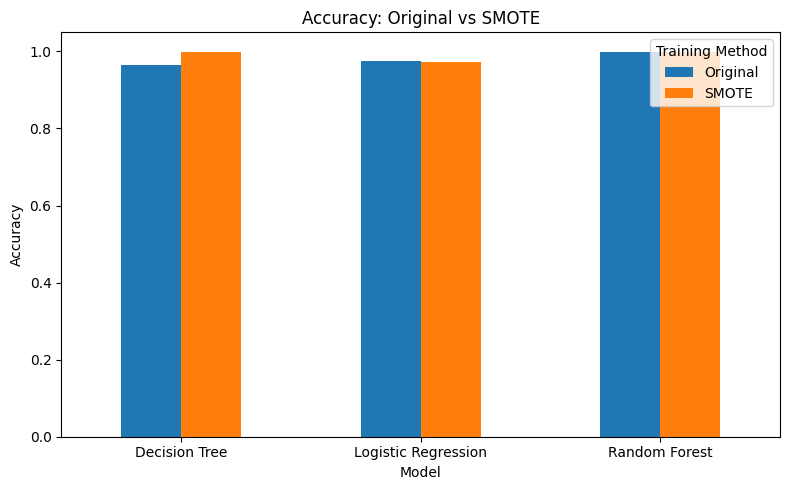

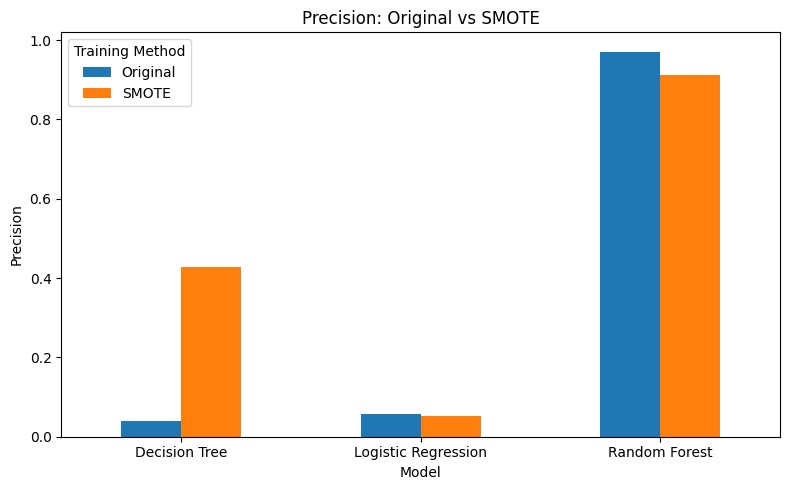

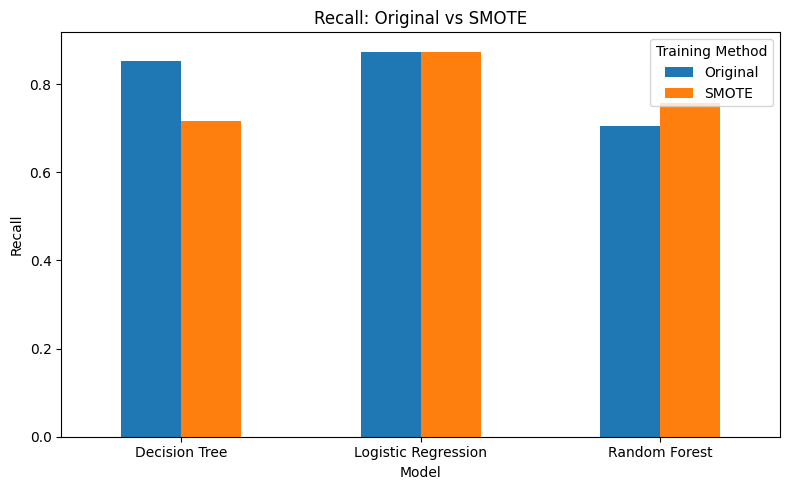

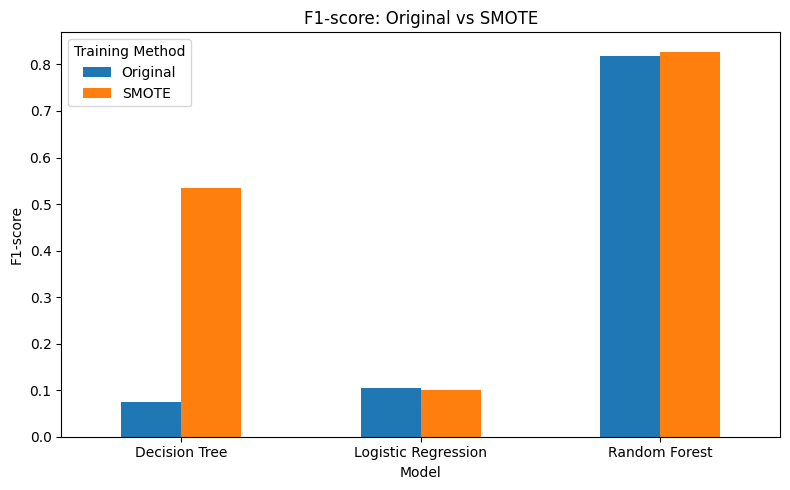

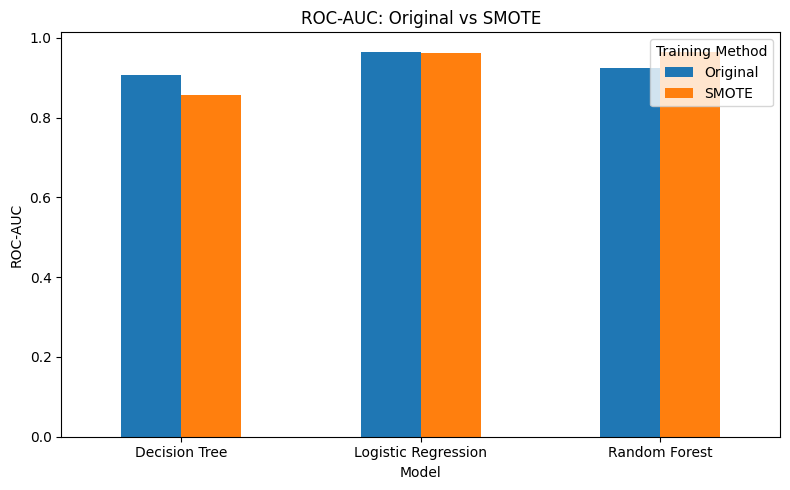

In [33]:
# =========================================================
# BAR CHARTS: ORIGINAL VS SMOTE
# =========================================================

for metric in metrics:
    pivot_table = comparison_df.pivot(index="Model", columns="Method", values=metric)
    pivot_table.plot(kind="bar", figsize=(8, 5))
    plt.title(f"{metric}: Original vs SMOTE")
    plt.ylabel(metric)
    plt.xticks(rotation=0)
    plt.legend(title="Training Method")
    plt.tight_layout()
    plt.show()

In [34]:
# =========================================================
# NUMERIC DIFFERENCE TABLE (SMOTE - ORIGINAL)
# =========================================================

original_indexed = original_results_df.set_index("Model")[metrics]
smote_indexed = smote_results_df.set_index("Model")[metrics]

difference_df = smote_indexed - original_indexed
difference_df = difference_df.reset_index()

print("\nDifference Table (SMOTE - Original):")
print(difference_df)


Difference Table (SMOTE - Original):
                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
0        Decision Tree  0.033483   0.388824 -0.136842  0.461121 -0.048971
1  Logistic Regression -0.001568  -0.003198  0.000000 -0.005665 -0.003943
2        Random Forest  0.000000  -0.059622  0.052632  0.010513  0.040998


In [35]:
# =========================================================
# INTERPRETATION SUMMARY
# =========================================================

print("\nINTERPRETATION SUMMARY")
print("="*60)

for _, row in difference_df.iterrows():
    model = row["Model"]
    precision_change = row["Precision"]
    recall_change = row["Recall"]
    f1_change = row["F1-score"]

    print(f"\n{model}:")
    print(f"- Precision change: {precision_change:+.4f}")
    print(f"- Recall change   : {recall_change:+.4f}")
    print(f"- F1-score change : {f1_change:+.4f}")

    if recall_change > 0 and precision_change < 0:
        print("- SMOTE improved recall but reduced precision, meaning the model catches more fraud but creates more false positives.")
    elif recall_change > 0 and precision_change > 0:
        print("- SMOTE improved both recall and precision, which means overall fraud detection performance became stronger.")
    elif recall_change < 0 and precision_change > 0:
        print("- SMOTE made the model more conservative: fewer false alarms, but more fraud cases may be missed.")
    else:
        print("- SMOTE did not clearly improve this model and may not be the best choice for it.")


INTERPRETATION SUMMARY

Decision Tree:
- Precision change: +0.3888
- Recall change   : -0.1368
- F1-score change : +0.4611
- SMOTE made the model more conservative: fewer false alarms, but more fraud cases may be missed.

Logistic Regression:
- Precision change: -0.0032
- Recall change   : +0.0000
- F1-score change : -0.0057
- SMOTE did not clearly improve this model and may not be the best choice for it.

Random Forest:
- Precision change: -0.0596
- Recall change   : +0.0526
- F1-score change : +0.0105
- SMOTE improved recall but reduced precision, meaning the model catches more fraud but creates more false positives.


In [36]:
# =========================================================
# BEST MODEL BY F1-SCORE
# =========================================================

best_original = original_results_df.loc[original_results_df["F1-score"].idxmax()]
best_smote = smote_results_df.loc[smote_results_df["F1-score"].idxmax()]

print("\nBest Original Model by F1-score:")
print(best_original)

print("\nBest SMOTE Model by F1-score:")
print(best_smote)


Best Original Model by F1-score:
Model        Random Forest
Accuracy          0.999471
Precision         0.971014
Recall            0.705263
F1-score          0.817073
ROC-AUC           0.924607
Method            Original
Name: 2, dtype: object

Best SMOTE Model by F1-score:
Model        Random Forest
Accuracy          0.999471
Precision         0.911392
Recall            0.757895
F1-score          0.827586
ROC-AUC           0.965606
Method               SMOTE
Name: 2, dtype: object


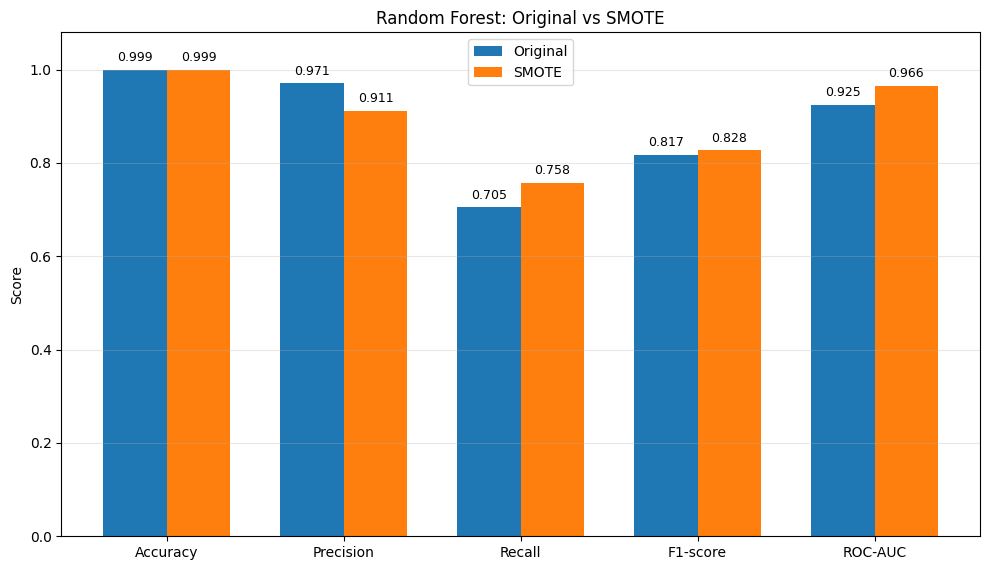

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

rf_compare = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Original": [0.999471, 0.971014, 0.705263, 0.817073, 0.924607],
    "SMOTE":    [0.999471, 0.911392, 0.757895, 0.827586, 0.965606],
})

# -------- Chart --------
fig, ax = plt.subplots(figsize=(10, 5.8))
x = list(range(len(rf_compare)))
width = 0.36

ax.bar([i - width/2 for i in x], rf_compare["Original"], width, label="Original")
ax.bar([i + width/2 for i in x], rf_compare["SMOTE"], width, label="SMOTE")

ax.set_xticks(x)
ax.set_xticklabels(rf_compare["Metric"])
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score")
ax.set_title("Random Forest: Original vs SMOTE")
ax.legend()
ax.grid(axis="y", alpha=0.3)

for i, val in enumerate(rf_compare["Original"]):
    ax.text(i - width/2, val + 0.012, f"{val:.3f}", ha="center", va="bottom", fontsize=9)
for i, val in enumerate(rf_compare["SMOTE"]):
    ax.text(i + width/2, val + 0.012, f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

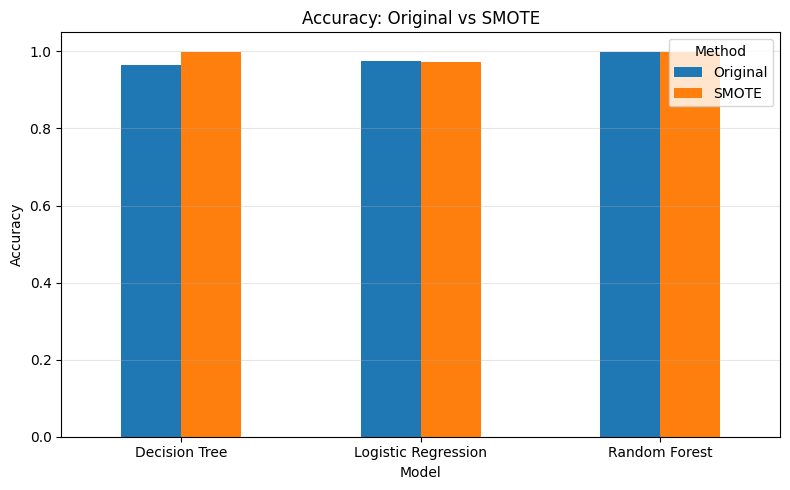

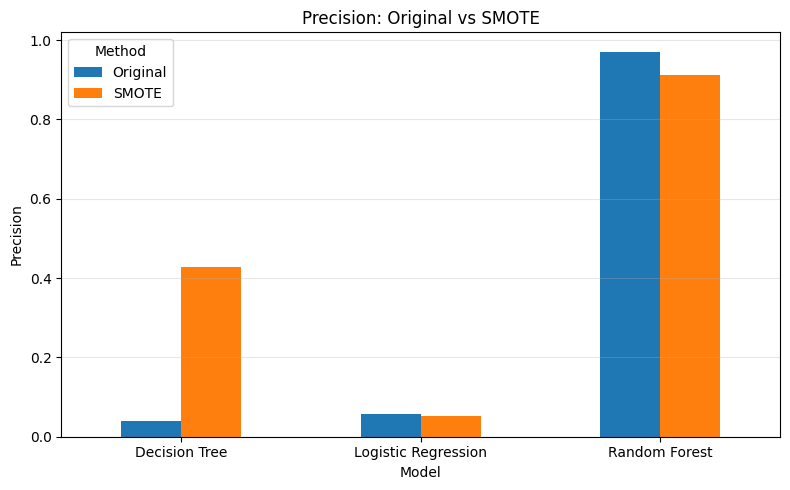

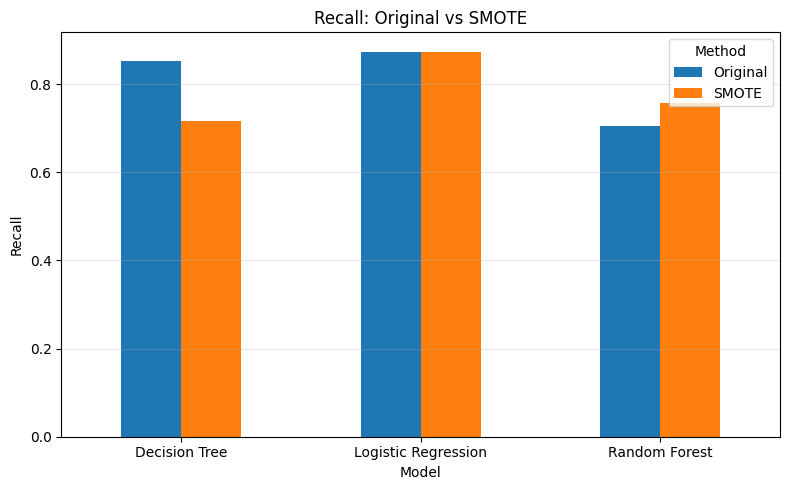

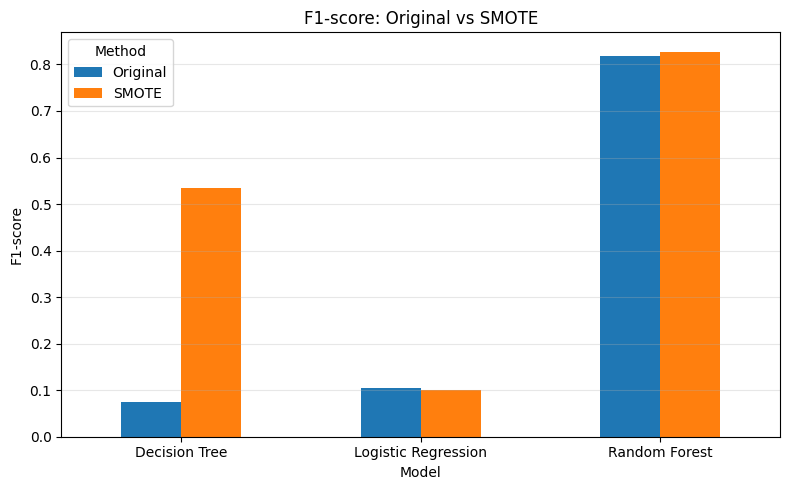

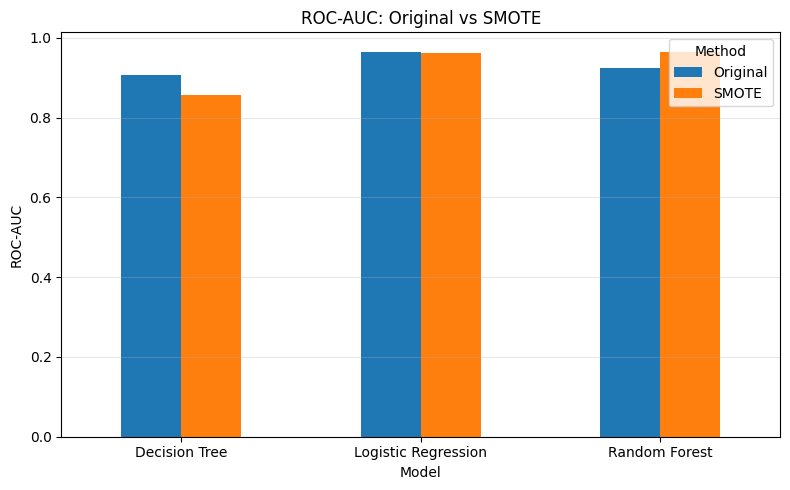

In [38]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

for metric in metrics:
    pivot_table = comparison_df.pivot(index="Model", columns="Method", values=metric)

    pivot_table.plot(
        kind="bar",
        figsize=(8,5)
    )

    plt.title(f"{metric}: Original vs SMOTE")
    plt.ylabel(metric)
    plt.xticks(rotation=0)
    plt.legend(title="Method")
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

In [39]:
print("\nOriginal Class Distribution:")
print(y_train.value_counts())

print("\nSMOTE Class Distribution:")
print(y_train_smote.value_counts())


Original Class Distribution:
Class
0    226602
1       378
Name: count, dtype: int64

SMOTE Class Distribution:
Class
0    226602
1    226602
Name: count, dtype: int64


In [40]:
# Before SMOTE
print("Original Training Shape:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

# After SMOTE
print("\nAfter SMOTE Shape:")
print("X_train_smote:", X_train_smote.shape)
print("y_train_smote:", y_train_smote.shape)

Original Training Shape:
X_train: (226980, 30)
y_train: (226980,)

After SMOTE Shape:
X_train_smote: (453204, 30)
y_train_smote: (453204,)


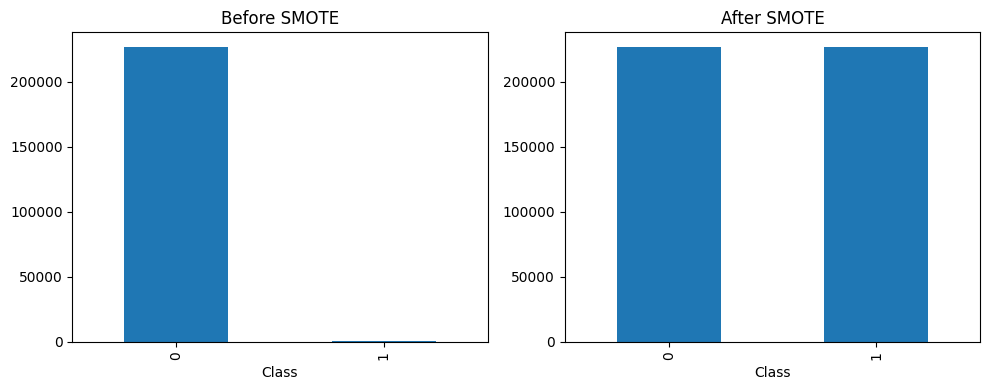

In [41]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10,4))

y_train.value_counts().plot(kind='bar', ax=axes[0], title="Before SMOTE")
y_train_smote.value_counts().plot(kind='bar', ax=axes[1], title="After SMOTE")

plt.tight_layout()
plt.show()